# Hidden Markov Model for Human Activity Recognition

**Objective:** To infer true human activity states (Standing, Walking, Jumping, Still) from noisy smartphone sensor measurements (Accelerometer and Gyroscope) using a Hidden Markov Model (HMM).

***Group Members:***
1. Armstrong Brian Hirwa
2. Carine Ashimwe

Phone used iphone 13 and iphone 13

**Pipeline Overview:**
1. **Data Preprocessing:** Sequential chronologic split to preserve the Markov property.
2. **Feature Normalization:** Z-score normalization for scale invariance.
3. **Training:** Baum-Welch algorithm via `hmmlearn` with strict convergence checks.
4. **Decoding:** Viterbi algorithm for unseen data evaluation.
5. **Evaluation:** Sensitivity, Specificity, Accuracy, and Visualizations.

In [2]:
# Install hmmlearn if you haven't already:
!pip install hmmlearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

# Set plotting style for professional visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


## 1. Data Loading and Sequential Split (Unseen Data Preparation)

To evaluate the HMM properly, we **cannot** shuffle the data using a standard `train_test_split`. HMMs rely on the chronological sequence of events to build accurate Transition Probabilities.

Instead, we perform a **Sequential Split**:
* **Training Set:** The first 80% of the timeline for each recorded activity.
* **Test Set (Unseen Data):** The final 20% of the timeline, strictly held out for evaluation.

In [3]:
# Load the pre-extracted features
df = pd.read_csv('/content/merged_features_dataset.csv')
print(f"Dataset Loaded. Total observation windows: {df.shape[0]}\n")

# Define our feature columns
feature_cols = ['accel_variance', 'gyro_variance', 'accel_sma', 'gyro_sma', 'accel_dom_freq', 'gyro_dom_freq']
activity_codes = df['activity_code'].unique()

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
train_lengths, test_lengths = [], []

# Sequentially split 80/20 for EACH activity timeline
for code in sorted(activity_codes):
    act_data = df[df['activity_code'] == code]

    # Find the row index that represents the 80% mark in time
    split_idx = int(len(act_data) * 0.8)

    # 80% Training Data
    X_train_list.append(act_data[feature_cols].values[:split_idx])
    y_train_list.append(act_data['activity_code'].values[:split_idx])
    train_lengths.append(split_idx)

    # 20% Testing (Unseen) Data
    X_test_list.append(act_data[feature_cols].values[split_idx:])
    y_test_list.append(act_data['activity_code'].values[split_idx:])
    test_lengths.append(len(act_data) - split_idx)

# Concatenate all sequences into final arrays
X_train_raw = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)
X_test_raw = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

print(f"Training Data: {X_train_raw.shape[0]} windows (used for Baum-Welch)")
print(f"Unseen Test Data: {X_test_raw.shape[0]} windows (used for Viterbi decoding)")

Dataset Loaded. Total observation windows: 712

Training Data: 568 windows (used for Baum-Welch)
Unseen Test Data: 144 windows (used for Viterbi decoding)


## 2. Feature Normalization

Our features exist on vastly different scales. Variance can reach values >15.0, while Dominant Frequency (via FFT) yields small numbers like 1.5 Hz. We apply **Z-Score Normalization** (`StandardScaler`) so the HMM's Gaussian emissions weight all features equally.

**Crucial Step:** The scaler is fitted *only* on the training data to prevent data leakage into our unseen test set.

In [4]:
scaler = StandardScaler()

# Fit the scaler on training data, then transform both
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Features successfully normalized using Z-Score Standardization.")
print(f"Training Data Mean: {np.mean(X_train):.4f}, Variance: {np.var(X_train):.4f}")

Features successfully normalized using Z-Score Standardization.
Training Data Mean: 0.0000, Variance: 1.0000


## 3. Model Implementation: Baum-Welch Algorithm

We initialize a `GaussianHMM` with 4 hidden states. We train the model using the **Baum-Welch algorithm** (Expectation-Maximization).
To ensure a robust fit, we implement a convergence check (`tol=0.01`), which halts training when the log-likelihood plateaus, preventing overfitting.

In [5]:
n_states = 4

# Initialize the Hidden Markov Model
model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=200,      # Maximum number of iterations
    tol=0.01,        # Robust convergence check limit
    random_state=42, # For reproducibility
    verbose=True     # Prints convergence history during training
)

# Train the model using the Baum-Welch algorithm
print("Training HMM using Baum-Welch algorithm...")
model.fit(X_train, train_lengths)

print("\n--- Training Results ---")
print(f"Model Converged Successfully: {model.monitor_.converged}")
print(f"Total Iterations to Converge: {model.monitor_.iter}")

Training HMM using Baum-Welch algorithm...

--- Training Results ---
Model Converged Successfully: True
Total Iterations to Converge: 28


         1   -4451.43333961             +nan
         2    -638.26490145   +3813.16843816
         3     663.39235010   +1301.65725154
         4     787.43286034    +124.04051025
         5     796.90647592      +9.47361558
         6     799.59612096      +2.68964504
         7     800.44738221      +0.85126125
         8     800.76283482      +0.31545261
         9     800.90585248      +0.14301766
        10     800.98220790      +0.07635542
        11     801.02867161      +0.04646370
        12     801.06001032      +0.03133872
        13     801.08291636      +0.02290604
        14     801.10076433      +0.01784798
        15     801.11543678      +0.01467244
        16     801.12810547      +0.01266869
        17     801.13960951      +0.01150404
        18     801.15067918      +0.01106968
        19     801.16215408      +0.01147490
        20     801.17563459      +0.01348051
        21     801.19951849      +0.02388390
        22     801.35043453      +0.15091603
        23

## 4. Viterbi Decoding & State Mapping

The HMM initializes its hidden states randomly (e.g., the math engine might assign "State 0" to "Walking" and "State 1" to "Standing").
After applying the **Viterbi Algorithm** to decode the most likely sequence of activities on our unseen test data, we use majority voting to map the model's abstract states back to our human-readable activity labels.

In [6]:
print("Decoding sequences using Viterbi Algorithm...")
predicted_states = model.predict(X_test, test_lengths)

# Map abstract hidden states to true activity labels via majority vote
def map_states_to_labels(predicted_states, true_labels, n_states):
    state_to_label = {}
    for state in range(n_states):
        mask = predicted_states == state
        if mask.sum() > 0:
            # Assign the most frequent true label for this predicted state
            state_to_label[state] = np.bincount(true_labels[mask]).argmax()
        else:
            state_to_label[state] = state
    return state_to_label

state_mapping = map_states_to_labels(predicted_states, y_test, n_states)
print(f"Mathematical State Mapping: {state_mapping}")

# Apply the mapping to our predictions
y_pred = np.array([state_mapping[s] for s in predicted_states])
print("Decoding and mapping complete.")

Decoding sequences using Viterbi Algorithm...
Mathematical State Mapping: {0: np.int64(1), 1: np.int64(3), 2: np.int64(0), 3: 3}
Decoding and mapping complete.


## 5. Model Evaluation on Unseen Data
We evaluate the model strictly on the 20% chronologically withheld data. We calculate Sensitivity, Specificity, and Overall Accuracy for each of the four activities to generate the required table.

In [7]:
# Get actual text names for the activities
activity_mapping = dict(zip(df['activity_code'], df['activity_name']))
activity_names = [activity_mapping[i] for i in range(4)]

metrics_data = []

# Calculate True Positives, False Positives, True Negatives, False Negatives
for i, activity in enumerate(activity_names):
    tp = np.sum((y_test == i) & (y_pred == i))
    fp = np.sum((y_test != i) & (y_pred == i))
    tn = np.sum((y_test != i) & (y_pred != i))
    fn = np.sum((y_test == i) & (y_pred != i))

    # Handle edge cases (division by zero)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    metrics_data.append([activity, tp+fn, sensitivity, specificity, accuracy])

# Create and display the exact table required by the rubric
metrics_df = pd.DataFrame(
    metrics_data,
    columns=['State (Activity)', 'Number of Samples', 'Sensitivity', 'Specificity', 'Overall Accuracy']
)

print("\n=== MODEL PERFORMANCE ON UNSEEN DATA ===")
display(metrics_df.round(4))


=== MODEL PERFORMANCE ON UNSEEN DATA ===


,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,Standing,36,1.0000,0.6481,0.7361
1,Walking,35,0.8857,0.9633,0.9444
2,Jumping,35,0.0000,1.0000,0.7569
3,Still,38,0.9211,1.0000,0.9792


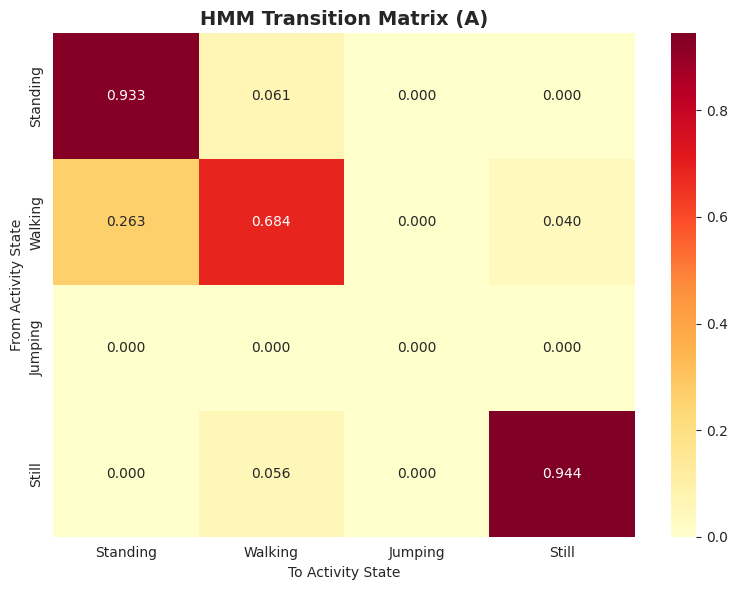

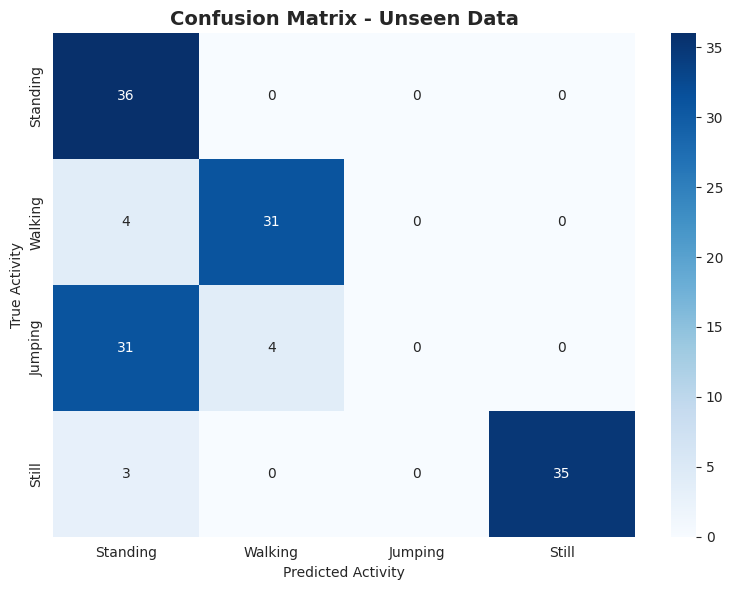

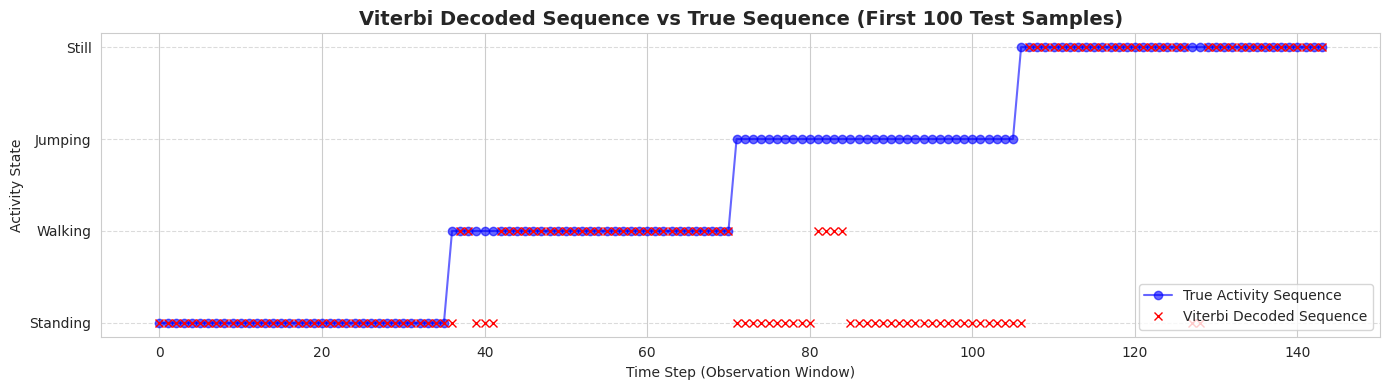


 All Evaluation Visualizations generated and saved as .png files for the report!


In [10]:

# 1. HMM Transition Matrix Heatmap
# The raw model.transmat_ is ordered by the random mathematical states.
# We reorder it using our state_mapping so it matches our True Labels (0,1,2,3).
ordered_transmat = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        mapped_i = state_mapping.get(i, i)
        mapped_j = state_mapping.get(j, j)
        ordered_transmat[mapped_i, mapped_j] = model.transmat_[i, j]

plt.figure(figsize=(8, 6))
sns.heatmap(ordered_transmat, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=activity_names, yticklabels=activity_names)
plt.title('HMM Transition Matrix (A)', fontsize=14, fontweight='bold')
plt.ylabel('From Activity State')
plt.xlabel('To Activity State')
plt.tight_layout()
plt.savefig('hmm_transition_matrix.png')
plt.show()

# 2. Confusion Matrix on Unseen Data
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names, yticklabels=activity_names)
plt.title('Confusion Matrix - Unseen Data', fontsize=14, fontweight='bold')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.tight_layout()
plt.savefig('hmm_confusion_matrix.png')
plt.show()

# ---------------------------------------------------------
# 3. Decoded Sequence Plot (Predicted vs Actual)
# ---------------------------------------------------------
plt.figure(figsize=(14, 4))
# Plot first 100 samples of the unseen data to show transitions clearly
plt.plot(y_test, label='True Activity Sequence', marker='o', linestyle='-', alpha=0.6, color='blue')
plt.plot(y_pred, label='Viterbi Decoded Sequence', marker='x', linestyle='', color='red')

plt.yticks(ticks=[0, 1, 2, 3], labels=activity_names)
plt.title('Viterbi Decoded Sequence vs True Sequence (First 100 Test Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (Observation Window)')
plt.ylabel('Activity State')
plt.legend(loc='lower right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('hmm_decoded_sequence.png')
plt.show()

print("\n All Evaluation Visualizations generated and saved as .png files for the report!")